<a href="https://colab.research.google.com/github/KhusbuBubna123/BreastCancerDetection/blob/main/Tuberculosis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip Tuberculosis_Dataset.zip

Archive:  Tuberculosis_Dataset.zip
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (1).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (10).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (100).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (101).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (102).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (103).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (104).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (105).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (106).jpg  
  inflating: Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (107).jpg  
  inflat

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import tqdm
import random
import PIL
from keras.preprocessing.image import load_img
warnings.filterwarnings('ignore')
import seaborn as sns

In [18]:
dic={}
input_path=[]
label=[]

for class_name in os.listdir("/content/Dataset of Tuberculosis Chest X-rays Images/"):
    for path in os.listdir("/content/Dataset of Tuberculosis Chest X-rays Images/"+class_name):
      if class_name == 'Normal Chest X-rays':
        l="Normal"
        label.append("Normal")
      else:
        label.append("Tuberculosis")
        l="Tuberculosis"
      p=os.path.join("/content/Dataset of Tuberculosis Chest X-rays Images/", class_name, path)
      input_path.append(p)
        #print(path)
      dic[p]=l
#print(input_path[25], label[25])
for (k,v) in dic.items():
  print(k,":",v,end='\n')

/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (427).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (288).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (180).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (436).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (6).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (267).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (192).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (419).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (141).jpg : Normal
/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (294).jpg : Normal
/content/Dat

In [64]:
df=pd.DataFrame(list(dic.items()), columns=['images', 'label'])
#df['images'] = input_path
#df['label'] = label

df = df.sample(frac=1).reset_index(drop=True) #To Shuffle the Images.
df.head(10)

,images,label
0,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis
1,/content/Dataset of Tuberculosis Chest X-rays ...,Normal
2,/content/Dataset of Tuberculosis Chest X-rays ...,Normal
3,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis
4,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis
5,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis
6,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis
7,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis
8,/content/Dataset of Tuberculosis Chest X-rays ...,Normal
9,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis


#Detecting db files.

In [41]:
for dbimage in df['images']:
    if '.jpg' not in dbimage:
        print(dbimage)

#Deleting Corrupted Files.

In [7]:
dataset_dir = "/content/Dataset_of_Tuberculosis_Chest_X-rays_Images/"

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        filepath = os.path.join(root, file)
        try:
            with Image.open(filepath) as img:
                img.verify() # Verify it's an actual image
        except (IOError, SyntaxError) as e:
            print(f'Bad or corrupted image found: {filepath}')
            os.remove(filepath) # Uncomment this line to automatically delete corrupted files

In [65]:
df.shape

(3008, 2)

#Plotting first 25 Normal Chest X Ray Images.

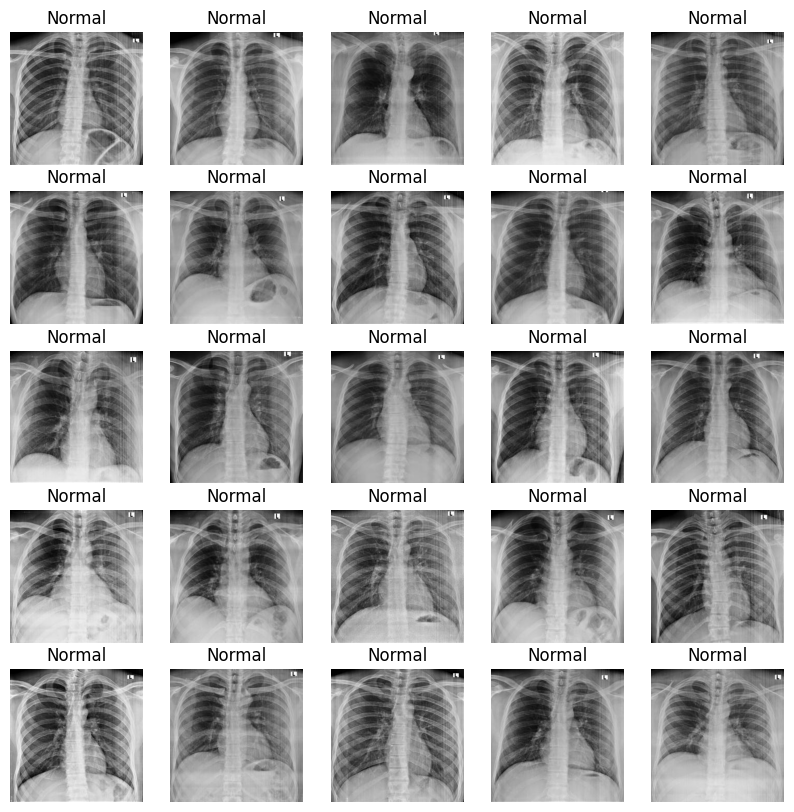

In [66]:
plt.figure(figsize=(10,10))
temp = df[df['label']=="Normal"]['images']
start = random.randint(0, len(temp))
                            #print(start)
                          #files = temp[start:start+25]
files=temp[0:25]       #Plotting first 25 Normal Chest X Ray Images images.
#plt.title("Normal Chest X ray Images", loc='center', fontsize=14, fontweight='bold', color='black', pad=15)
#print("\n \n \n")

for index, file in enumerate(files):
    plt.subplot(5,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Normal')


#Plotting first 25 Tuberculosis Chest X Ray images.

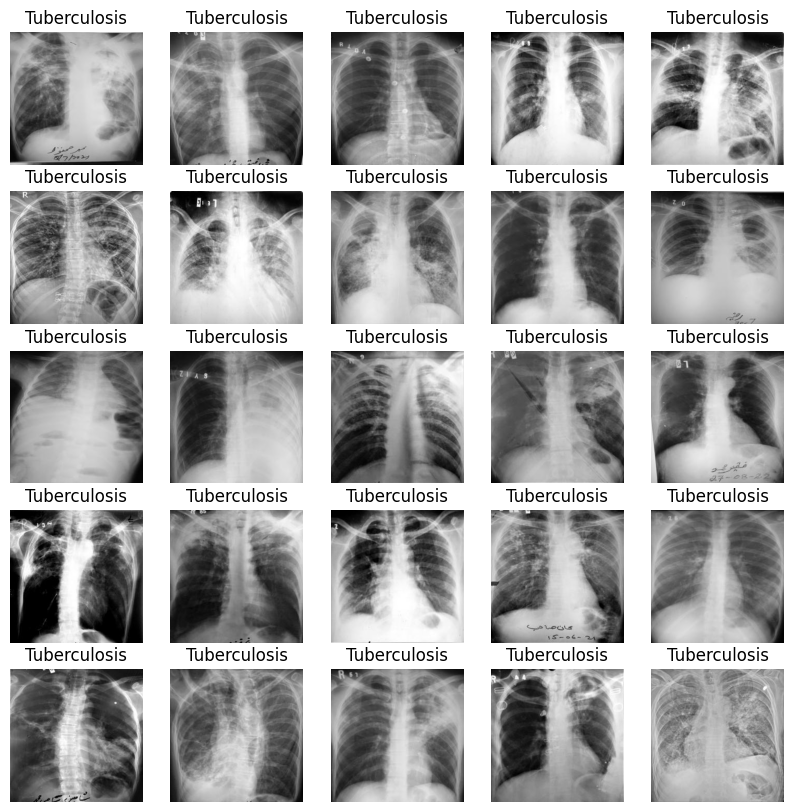

In [67]:
plt.figure(figsize=(10,10)) #Plotting First 25 Tuberculosis Chest X Ray Images.
temp = df[df['label']=="Tuberculosis"]['images']
#start = random.randint(0, len(temp))
#print(start)
#files = temp[start:start+25]
files=temp[0:25] #Plotting first 25 images.
#plt.title("Tuebrculosis Chest X ray Images", loc='center', fontsize=14, fontweight='bold', color='black', pad=15)
print("\n \n \n")
for index, file in enumerate(files):
    plt.subplot(5,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Tuberculosis')
    plt.axis('off')

<Axes: xlabel='count', ylabel='label'>

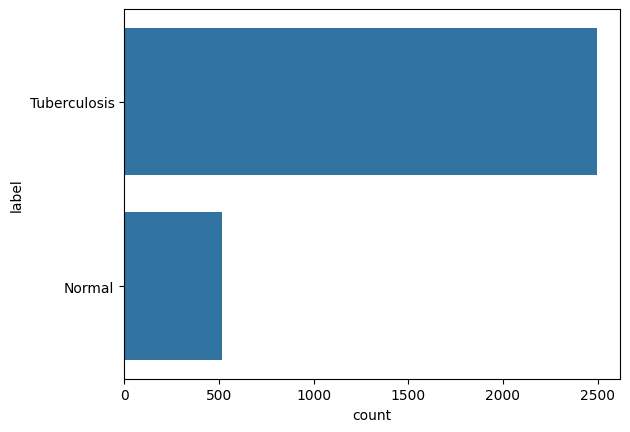

In [68]:
sns.countplot(df['label'])
#plt.xticks(rotation=90)
#plt.xticks(rotation=90, ha='right')
#plt.show()

In [69]:
df['label']=df['label'].astype("str")
df.head()

,images,label
0,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis
1,/content/Dataset of Tuberculosis Chest X-rays ...,Normal
2,/content/Dataset of Tuberculosis Chest X-rays ...,Normal
3,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis
4,/content/Dataset of Tuberculosis Chest X-rays ...,Tuberculosis


In [71]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(df,test_size=0.2,random_state=42)

In [72]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.src.legacy.preprocessing.image import ImageDataGenerator
train_generator=ImageDataGenerator(
    rescale=1/255,
    rotation_range=40, #To avoid overfitting.
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
val_generator=ImageDataGenerator(rescale=1/255)
train_iterator=train_generator.flow_from_dataframe(
       train,
       x_col='images',
       y_col='label',
       target_size=(128,128),
       batch_size=512,
       class_mode='binary'
)

Found 2406 validated image filenames belonging to 2 classes.


In [84]:
val_iterator = val_generator.flow_from_dataframe(
    test,
    x_col='images',
    y_col='label',
    target_size=(128,128),
    batch_size=512,
    class_mode='binary'
)

Found 602 validated image filenames belonging to 2 classes.


In [156]:
from keras import Sequential
from keras.layers import Conv2D,MaxPool2D,Flatten,Dense
model = Sequential([
                    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
                    MaxPool2D((2,2)),
                    Conv2D(32, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Conv2D(128, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Conv2D(256, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dense(1, activation='sigmoid')
                    #Dense(2, activation='softmax')
])

In [157]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_75 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 917,921 (3.50 MB)

 Trainable params: 917,921 (3.50 MB)

 Non-trainable params: 0 (0.00 B)

In [158]:
history = model.fit(train_iterator, epochs=3, validation_data=val_iterator)

Epoch 1/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 64s 12s/step - accuracy: 0.6870 - loss: 0.5269 - val_accuracy: 0.8090 - val_loss: 0.4779
Epoch 2/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 60s 11s/step - accuracy: 0.8342 - loss: 0.4343 - val_accuracy: 0.8090 - val_loss: 0.4842
Epoch 3/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 61s 12s/step - accuracy: 0.8342 - loss: 0.4266 - val_accuracy: 0.8090 - val_loss: 0.4522


#Results

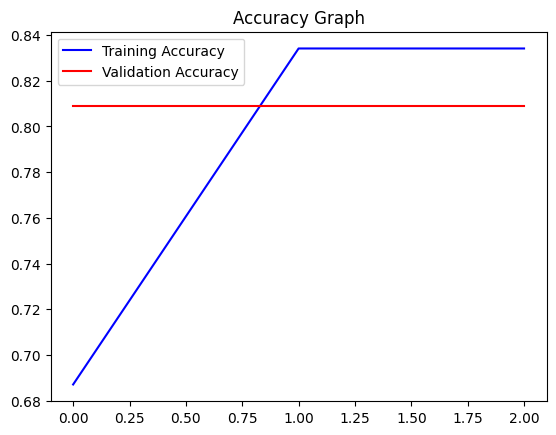

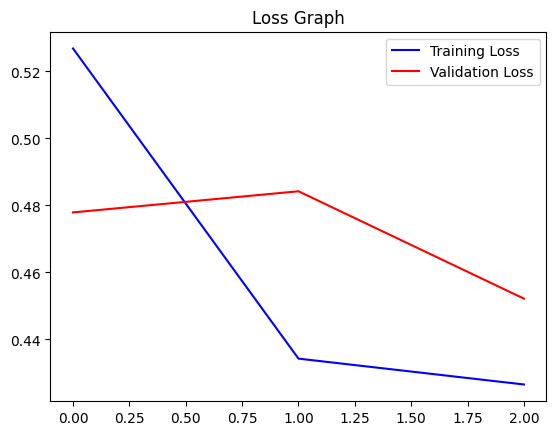

In [164]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

#Testing on Unseeen Chest X Ray Images.

#Testing on Tuberculosis Chest X Ray Image.

In [165]:

#image_path="/content/Dataset of Tuberculosis Chest X-rays Images/TB Chest X-rays/TB.1008.jpg"
#image_path="/content/Dataset of Tuberculosis Chest X-rays Images/TB Chest X-rays/TB.1023.jpg"

image_path="/content/TuberculosisTest.jpg"
img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
img = img / 255.0 # normalize the image
img = img.reshape(1, 128, 128, 3) # reshape for prediction
pred = model.predict(img)
print(pred)  #Using Sigmoid Activation Function.

# Classify as 0 or 1 based on a 0.5 threshold
class_label = 1 if pred >= 0.5 else 0

print(class_label)


if(predicted_class==1):
  print("The patient is Normal")
elif(predicted_class==0):
  print("The patient is suffrening from Tuberculosis.")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
[[0.8300348]]
1
The patient is suffrening from Tuberculosis.


#Testing on Normal Chest X Ray Image.(Without Tuberculosis).

In [166]:
#image_path="/content/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays/others (101).jpg"
image_path="/content/Normal_Image.jpg"
img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
img = img / 255.0 # normalize the image
img = img.reshape(1, 128, 128, 3) # reshape for prediction
pred = model.predict(img)
print(pred)  #Using Softmax Activation Function.

# Classify as 0 or 1 based on a 0.5 threshold
class_label = 1 if pred >= 0.5 else 0

print(class_label)


if(predicted_class==0):
  print("The patient is Normal")
elif(predicted_class==1):
  print("The patient is suffrening from Tuberculosis.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[0.80383193]]
1
The patient is Normal


In [ ]:
'''
if score[0] > 0.5: #Using Sigmoid Activation Function. Sigmoid probability output.
    label = 'Tuberculosis'
else:
    label = 'Normal'
print(label)
Interpret the binary result

if score >= 0.5:
    predicted_class ="Normal"
    confidence = score
else:
    predicted_class =""
    confidence = 1 - score

#print(f"Predicted Class: {predicted_class} ({confidence * 100:.2f}% Confidence)")
print("Predicted Class", predicted_class,"with",confidence,"%")'''